# **Detector de Conflitos em Textos - PGC UFABC**

Espaço para desenvolvimento, teste e implementação do modelo de detecção de conflitos em textos, proposto no Projeto de Graduação em Computação da Universidade Federal do ABC



**Orientandos:**

*   Caio Cardoso dos Santos
*   Victor Ravazio de Lima

**Orientador:**

*   Prof. Dr. Carlos da Silva dos Santos




# **Conceitos e direções**

## **Conceiros essenciais - Super Resumo**



*   BERT - Modelo de Linguagem baseado em Transformers - Aprende relações semanticas profundas em textos

*   BERTimbau - BERT pré-treinado em portugês Br

*   Tokenizer - converte texto em numeros (IDS), onde cada inteiro é um indice no vocabulo.

  EX: "Eu adorei esse produto" => input_ids = [101, 1198, 17842, 1239, 15323, 102].
  
  Basicamento o Bert possui um dicionario estático e cada valor desse vetor de input corresponde a posição em que determinada palavra ou prefixo está localizada neste dicionario.


*   Fine-tuning - Ajustar o modelo para a tarefa especifica
*   Modelo: [neuralmind/bert-base-portuguese-cased](https://https://huggingface.co/neuralmind/bert-base-portuguese-cased)

**Fonte:** @inproceedings{souza2020bertimbau,
  author    = {F{\'a}bio Souza and
               Rodrigo Nogueira and
               Roberto Lotufo},
  title     = {{BERT}imbau: pretrained {BERT} models for {B}razilian {P}ortuguese},
  booktitle = {9th Brazilian Conference on Intelligent Systems, {BRACIS}, Rio Grande do Sul, Brazil, October 20-23 (to appear)},
  year      = {2020}
}

Fontes auxiliares e projetos:

Fonte 2: https://arthuremanuel-carosia.medium.com/usando-o-bert-para-an%C3%A1lise-de-sentimentos-363f76eee15e

Fonte 3: https://gist.github.com/Hugobsan/b507b76c7b5fc470d77b3a924211430d#file-pr-processamento-ipynb




##**Pipeline idealizado (provisório?)**


Dado o Dataset com Tweets:

*   Cada Dataset temático é divido em 3 subestruturas: Tweets genéricos, repys e quotes


  
*   Gera-se pares de tweets dentro de uma mesma subestrutura: Reply com seu respectivo replied tweet; Quote com seu respsctivo Quoted tweet; e original pareado com outro tweet origginal de forma aleatoria (amostragem aleatoria)

*   Para cada par de frases de cada grupo, constrói um dataset com essas informações: frase_1 - frase_2 - Classe - conflito (0/1)
*   Esta tabela seria o dataset de entrada para o bert - Este então aprende os padrões textuais que geralmente associam conflitos - “Que tipo de relação semântica entre frase_1 e frase_2 gera um situação de conflito 1?” -  Ex: bom x ruim; ótimo x péssimo

*   O modelo no fim é necessário pois ele aprende uma fronteira suave e não discreta.






# **Preparação do ambiente**


## **Validando GPU**

In [ ]:
!nvidia-smi #verificando se o ambiente está configurado para GPU


Fri May 29 19:49:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             32W /   70W |    2303MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Instalando bibliotecas**

**Sobre as bibliotecas:**


*   Transformers (coleção de modelos pré-treinados em Transformers)
*   datasets (fornece alguns datasets otimizados prontos)
*   accelerate (gerencia multi gpu/otimiza treino em gpu)
*   evaluate (biblioteca de metricas padronizadas)

*   PyTorch (framework de deep learning)

* As 4 primeiras pertencem ao Hugging Face, espécie de "GitHub" de modelos IA







In [ ]:
#Instalando:
!pip install -q transformers datasets torch accelerate evaluate

In [ ]:
#!pip install torchcodec

In [ ]:
!pip install --upgrade datasets transformers


In [ ]:
#!pip install torchvision==0.21.0 #caso ocorra erro no treinamento, necessario instalar versão anaterior do torchvision

In [ ]:
# modulo para importar dataset a partir de um link
!pip install gdown

# **Importações**

## **Importando Bibliotecas**

**Sobre as bibliotecas:**

*  Torch (Framework para aplicações de machine learn: abstrai tarefas, operacionaliza manipulação de tensores e etc)

*  BertTokenizer(Tokenizar textos)
*   BertModel (Bert puro)
*   BertForSequenceClassification (BERT + Camada de classificador)
*   Trainer (modulo para treino)

*   TrainigArguments (modulo para treino)

*   Gdown (baixar arquivos direto do drive)

* Dataset (otimiza e facilita a formatação do datataset para treino no Bert)

* sklearn (biblioteca que fornece ferramentas prontas para realizar tarefas de ML, como por exemplo "train_test_split" que divide automaticamente treino e teste, ou as metricas de avaliação que abstrai os calculos de precisão, recall e etc)






In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gdown

from transformers import (
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



## **Importando o Modelo**

In [ ]:
#Tokenizer
tokenizer = BertTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

#Modelo: BERT + Camada de classificação
#num_labels corresponde ao numero de classes do modelo (Conflito/não conflito)
model = BertForSequenceClassification.from_pretrained("neuralmind/bert-base-portuguese-cased", num_labels = 2, problem_type="single_label_classification")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

## **Importando o dataset**

In [ ]:
# baixando dataset para o collab
file_id = "1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset_conflitos.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Op1OxN9N1Ul82YHIiarb3kIq1FSbCdcx
To: /content/dataset_conflitos.csv
100%|██████████| 314k/314k [00:00<00:00, 51.7MB/s]


'dataset_conflitos.csv'

In [ ]:
#carregando o dataset
df = pd.read_csv ("dataset_conflitos.csv")
df['Conflict'] = df['Conflict'].astype(int) #convertendo valores para inteiros
df = df[df['Conflict'] != -1] #eliminando indeterminados
df.shape

(1081, 4)

In [ ]:
#Verificando distribuição das classes
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  859
1 - Conflitos:  222
Desbalanceamento: 3.869 : 1


In [ ]:
#embaralhando o dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df

,tweet_1,tweet_2,Class,Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,"É simples ,quem for de direita toma a cloroqu...",1,1
1,Todo o dia uma ilusão diferente meu pai pq fiz...,"Alexandre de Moraes não passou dos limites , e...",0,0
2,Gabriela me ensinou que a gente deve ficar ate...,A mesma varela que tá comemorando as contas qu...,2,0
3,USE VPN onde a censura dos paises atrasados nã...,O desembargador de Santos é o retrato da Justi...,0,0
4,A maioria esmagadora dos brasileiros é contrár...,por estas e outras q vc justifica não ter nenh...,2,1
...,...,...,...,...
1076,Enquanto o presidente brinca de cloroquina est...,minha cidade é um interior do interior e hoje ...,0,0
1077,Lula e Bolsonaro são criticados juntos por fra...,a vdd é q nem Cloroquina e nem Tubaína vai ser...,2,0
1078,Vamos começar a pressão ao STF já. #AbortoNAO,O país sofrendo com mortos e o STF? #AbortoNAO,1,0
1079,"O ministro da Saúde, Henrique Mandetta, disse ...","confirmado galera, quarentena não vai acabar a...",2,0


## **Balanceamento provisorio para testes**

In [ ]:
#----------------Equilibrando dados---------------------------
df_conflitos = df[df["Conflict"] == 1]
df_nao_conflitos = df[df["Conflict"] == 0]
df_nao_conflitos = df_nao_conflitos.sample(n=df_conflitos.shape[0]*2, random_state=42)

df = pd.concat([df_conflitos, df_nao_conflitos])

In [ ]:
#Verificando novas distribuições das classes
conflitos = df[df["Conflict"] == 1].shape[0]
nao_conflitos = df[df["Conflict"] == 0].shape[0]
print("Quantidade de anotações por classes:")
print("0 - Não Conflitos: ", nao_conflitos)
print("1 - Conflitos: ", conflitos)
print(f"Desbalanceamento: {(max(nao_conflitos, conflitos) / min(nao_conflitos, conflitos)):.3f} : 1")

Quantidade de anotações por classes:
0 - Não Conflitos:  444
1 - Conflitos:  222
Desbalanceamento: 2.000 : 1


# **Modelo - Conflict Detector**

## **Separando treino e teste**

In [ ]:
#Separando dados em treino e teste
# train_test_split é um método da biblioteca sklearn que abstrai a divisão de treino e test
# O parametro stratify mantém a proporção das classes - Originalmente 80% não conflito e 20% não conflito, assim também será em train e test.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Conflict"])

#convertendo para o formato "datasets" do Hugging face - Abstrai alguns procedimentos, como formatar para tensores e etc
train_dataset = Dataset.from_pandas(train_df, preserve_index=False) #index = false - não inclui os indices do df original
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)


In [ ]:
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'Conflict'],
    num_rows: 532
})

## **Tokenização**

1 - Tokenização consiste em transformar o texto bruto em uma representação numérica estruturada que o modelo BERT consiga processar. Para isso, o texto é dividido em subpalavras (subword tokenization), e cada token é convertido em um identificador numérico correspondente ao índice no vocabulário aprendido pelo modelo.

O processo de tokenização gera três principais componentes:

- input_ids: sequência de identificadores numéricos dos tokens.
- token_type_ids: indica a qual sentença cada token pertence (no caso de pares de sentenças).
- attention_mask: indica quais posições são tokens reais (1) e quais são padding (0).

Na abordagem adotada neste trabalho, a tokenização é feita em pares de tweets, explorando a arquitetura do BERT, que permite modelar relações entre duas sentenças simultaneamente. Dessa forma, o modelo aprende interações semânticas entre os dois textos, em vez de processá-los isoladamente.

A entrada do BERT segue o formato:

[CLS] texto_1 [SEP] texto_2 [SEP]

Para construir essa entrada, utiliza-se o tokenizer do BERT, passando ambos os textos como parâmetros, além de argumentos de controle como padding (para padronizar o tamanho das sequências) e truncation (para limitar o tamanho máximo).

Esses vetores tokenizados são então utilizados como entrada do modelo, que gera embeddings contextualizados para cada token.

Observação: o padding é necessário para garantir que todas as sequências de um batch tenham o mesmo tamanho, já que o processamento é realizado em lotes (batches). Isso é essencial para a eficiência computacional e compatibilidade com o formato esperado pelo modelo.

2 - Este processo é realizado através da função tokenize_function, que aplica o tokenizer do BERT (carregado na etapa de importação) em cada elemento do dataset. No caso deste trabalho, a tokenização é aplicada a pares de tweets.


3 - O metodo "map" a seguir, que pertence a biblioteca "datasets" do Hugging Face, aplica tokenize_function em cada entrada do df e faz o merge do resultado com as colunas originais
EX:
    # originaal:'tweet_1', 'tweet_2', 'Class', 'Conflict;
    # Tokenize: 'input_ids', 'token_type_ids', 'attention_mask'
    # Map: 'tweet_1', 'tweet_2', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'
     
Naturalmente "train_dataset" e "test_dataset" é um objeto "Dataset" (da biblioteca do hugging face)

In [ ]:
#Função de tokenização
def tokenize_function(pair):

    return tokenizer(
        pair["tweet_1"],
        pair["tweet_2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
#Aplicando a Tokenização
train_dataset = train_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)

Map:   0%|          | 0/532 [00:00<?, ? examples/s]

Map:   0%|          | 0/134 [00:00<?, ? examples/s]

In [ ]:
#Formato pós tokenização
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'Conflict', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 532
})

In [ ]:
#Exemplo
print(train_dataset[0])

{'tweet_1': 'eu digo #AbortoSim pq preferiria q minha mae tivesse me abortado ao invés de sumir  e meu pai só me ajuda um pouco, bem pouco, por obrigação e pq ele tem um salario fixo e q se tbm n ajudasse n faria diferença pra mim pq ganho o suficiente pra me manter', 'tweet_2': 'e agr ja sou de maior e ja terminei a escola mas quando minha mae resolveu sumir eu ainda era de menor e tava na escola, e só dei conta pq ja trabalhava  e isso é fichinha perto de muitas outras situações q muitas crianças passam', 'Class': 2, 'Conflict': 0, 'input_ids': [101, 2779, 2826, 22280, 108, 2090, 2532, 22280, 22308, 314, 126, 22298, 5674, 7518, 100, 7122, 223, 22279, 6344, 311, 10363, 487, 320, 5972, 125, 20158, 307, 122, 7343, 1568, 1203, 311, 2565, 222, 1695, 117, 1004, 1695, 117, 240, 16871, 122, 126, 22298, 368, 376, 222, 4767, 342, 14654, 122, 100, 176, 160, 22295, 22287, 149, 2565, 22281, 236, 149, 11610, 5416, 1174, 9726, 126, 22298, 12650, 146, 4974, 1174, 102, 122, 762, 22282, 1941, 7206, 12

In [ ]:
# Renomeando o atributo alvo - O modulo trainer espera o atributo alvo numa coluna "label"
train_dataset = train_dataset.rename_column("Conflict", "labels")
test_dataset = test_dataset.rename_column("Conflict", "labels")
train_dataset

Dataset({
    features: ['tweet_1', 'tweet_2', 'Class', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 532
})

## **Formatando Tensores**

O Bert trabalha com tensores PyTorch, sendo necessária a conversão dos dados para este formato antes do treinamento.

Após a tokenização, os dados ainda estão em estruturas Python comuns (listas e inteiros). Para resolver isso, a biblioteca Datasets é bastante conveniente, pois o método set_format configura o dataset para que, no momento do acesso aos elementos (de forma lazy), as colunas especificadas sejam automaticamente convertidas para torch.Tensor.

O uso da biblioteca Datasets abstrai a necessidade de implementar manualmente uma classe "Dataset" do PyTorch (com métodos como __getitem__ e __len__), simplificando significativamente o pipeline de pré-processamento.

Pós-tokenização:
dataset[0] retorna:

"input_ids": [101, 2023, 2003],
"attention_mask": [1, 1, 1],
"labels": 1

Pós-formatação (set_format):
dataset[0] retorna:

"input_ids": tensor([...]),
"attention_mask": tensor([...]),
"labels": tensor(...)

     

In [ ]:
# Formatando os Tensores:

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "token_type_ids", "attention_mask", "labels"]
)

## **Métricas de avaliação**

Durante o treinamento, o Trainer (que será descrito na seção a seguir) avalia o modelo ao final de cada época utilizando um "eval_dataset" (metrica do trainer que corresponde ao conjunto de avaliação). Basicamente o modelo, ao fim de cada epoca, tenta realizar predições nos dados do eval_dataset (aqui, provisoriamente o proprio conjunto de teste esta sendo usado como avaliação). As saídas produzidas pelo modelo (logits) neste conjunto de avaliação são então convertidas em classes previstas e comparadas com os labels reais do dataset.

Em segguida, calcula-se as métricas de avaliação como accuracy, precision, recall e F1-score para medir a qualidade o modelo após cada época.

O Trainer então salva checkpoints do modelo durante o treinamento e utiliza o F1-score para identificar qual versão obteve o melhor desempenho.

A função a seguir, que realiza este processo de avaliação, será chamada automaticamente no final de cada época pelo Trainer (biblioteca pré carregada). O treiner, é configurado para realizar este processamento através de parametros durante sua chamada e pode ou não utilizar esta mecanica descrita, atraves da sobrecarga (passar parametros basicos só para treina, ou passar mais parametros, incluindo a função a seguir, indicando que quer realizar esta mecanica)  

Ao final do treinamento, o Trainer recarrega automaticamente o checkpoint com melhor F1-score.


In [ ]:
#computando metricas de avaliação
# eval_pred é o que o modelo previu no conjunto de avaliação e seus rotulos reais
# Essa função é chamada pelo "Trainer"
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    precision = precision_score(labels, predictions)

    recall = recall_score(labels, predictions)

    f1 = f1_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## **Treinamento**

A biblioteca Hugging Face fornece duas classes principais para o treinamento de modelos Transformer:  TrainingArguments e Trainer. Essas classes abstraem grande parte do processo de treinamento, evitando a necessidade de criar manualmente todo o loop de treino.

O TrainingArguments funciona como uma configuração geral que nos permite "personalizar" como o treinamento será executado. Nele podemos definir parâmetros como:  número de épocas, batch size, learning rate estratégia de avaliação, estratégia de salvamento, diretórios de logs e checkpoints

Já o Trainer é a classe responsável por executar o treinamento propriamente dito, utilizando o modelo, os datasets, os parâmetros definidos em TrainingArguments e a função de métricas. Durante o treinamento, a cada época, o Trainer percorre o dataset de treino em batches e, a cada batch, o modelo realiza o forward pass (processo em que os dados de entrada são propagados pela rede neural para gerar uma predição, basicamente calcular a saída para uma entrada específica). Em seguida, calcula-se a loss e realiza-se a agragação dos valores calculados da loss de cada item da batch (formando assim uma unica loss para a batch), executa-se a backpropagation e os pesos da rede são atualizados. Essas atualizações ocorrem batch a batch.

Após todos os batches de uma época serem processados, o Trainer executa automaticamente uma etapa de avaliação utilizando o eval_dataset (conjunto de validação fornecido na instanciação do Trainer). Nessa etapa, o modelo realiza o forward pass sobre os dados de validação e produz logits, que são os valores brutos de saída da rede neural antes da aplicação de uma função de ativação. Em seguida, esses logits são convertidos em classes por meio da seleção do maior valor (argmax). O Trainer então chama automaticamente a função compute_metrics(), responsável por calcular as métricas de avaliação a partir dessas predições.

In [ ]:
#Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01, #controla tamanho dos pesos para evitar overfitting
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# Treinando:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.637494,0.598352,0.664179,0.000000,0.000000,0.000000
2,0.566425,0.509200,0.761194,0.709677,0.488889,0.578947
3,0.477050,0.475855,0.776119,0.674419,0.644444,0.659091
4,0.382752,0.481243,0.791045,0.680851,0.711111,0.695652


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=268, training_loss=0.5159300334417998, metrics={'train_runtime': 179.2049, 'train_samples_per_second': 11.875, 'train_steps_per_second': 1.495, 'total_flos': 139975081451520.0, 'train_loss': 0.5159300334417998, 'epoch': 4.0})

In [ ]:
# avaliando
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.382752,0.481243,4,0.791045,0.680851,0.711111,0.695652


{'eval_loss': 0.4812431335449219, 'eval_accuracy': 0.7910447761194029, 'eval_precision': 0.6808510638297872, 'eval_recall': 0.7111111111111111, 'eval_f1': 0.6956521739130435}


In [ ]:
# Testando
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=-1)

print(
    classification_report(
        test_dataset["labels"],
        preds
    )
)

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        89
           1       0.68      0.71      0.70        45

    accuracy                           0.79       134
   macro avg       0.77      0.77      0.77       134
weighted avg       0.79      0.79      0.79       134



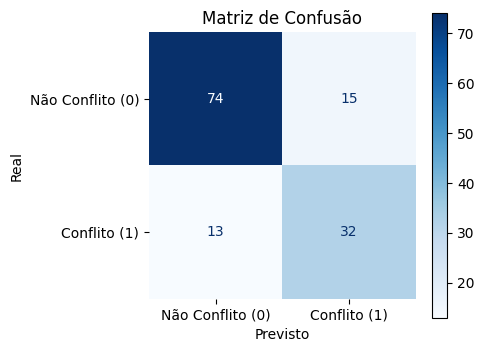

In [ ]:
#MATRIZ DE CONFUSÃO
#obtendo as classes previstas e reais
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

# nomes das classes
labels = ["Não Conflito (0)", "Conflito (1)"]

# matriz
mat = confusion_matrix(y_true, y_pred)

# plot
fig, ax = plt.subplots(figsize=(5,4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mat,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

# alterar nome dos eixos
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")

# remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(False)

plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()